# Análise de epítopos de células B


Resumo MM-GBSA:
     Epitope    n        mean         sd
0  Epitope 1  199  -26.051457  10.274834
1  Epitope 2  201 -107.746368   6.784203
2  Epitope 3  192  -79.375000  14.160177

Comparações estatísticas contra Epitope 1:
     Epitope              Comparison  t_statistic        p_value  \
0  Epitope 2  Epitope 2 vs Epitope 1    93.741591  2.586435e-246   
1  Epitope 3  Epitope 3 vs Epitope 1    42.491377  9.658801e-140   

      p_adjusted significance  
0  5.172870e-246         ****  
1  9.658801e-140         ****  


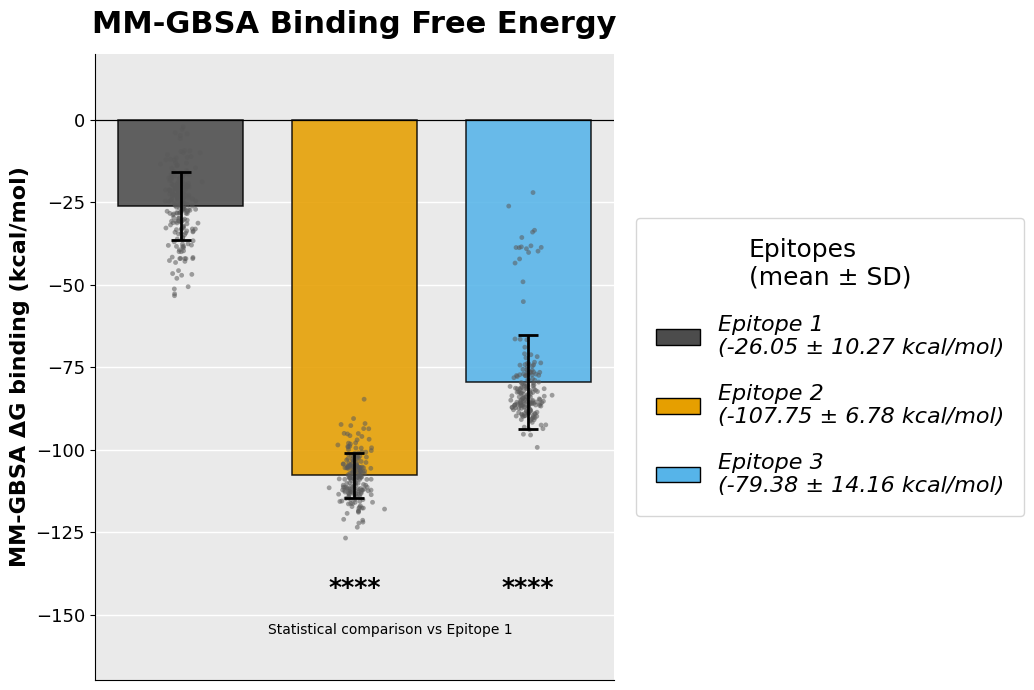

In [ ]:
# ============================================================
# MM-GBSA - Barplot com média ± desvio padrão
# Comparação estatística contra Epitope 1
#
# Ajustes:
# - fundo cinza no gráfico;
# - cada epítopo com uma cor diferente;
# - legenda no lugar do eixo X;
# - legenda com média ± desvio padrão abaixo do nome do epítopo;
# - remoção de valores positivos;
# - pontos experimentais uniformes e suaves;
# - barra de erro visível;
# - asteriscos de significância na parte inferior;
# - sem barras horizontais de comparação estatística;
# - significância sempre calculada contra Epitope 1.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Arquivos de entrada
# ------------------------------------------------------------

files = {
    "Epitope 1": "prime_mmgbsa_ultimos20ns_md_400ns_8WO1_conf_epitope_peptide1_hpv16_e6_bcell.csv",
    "Epitope 2": "prime_mmgbsa_ultimos20ns_md_400ns_8WO1_conf_epitope_peptide2_hpv16_e6_bcell.csv",
    "Epitope 3": "prime_mmgbsa_ultimos20ns_md_400ns_8WO1_conf_epitope_peptide3_hpv16_e6_bcell.csv",
}

epitopes_order = [
    "Epitope 1",
    "Epitope 2",
    "Epitope 3",
]

# ------------------------------------------------------------
# 2. Cores das barras por epítopo
# ------------------------------------------------------------

epitopes_colors = {
    "Epitope 1": "#4C4C4C",
    "Epitope 2": "#E69F00",
    "Epitope 3": "#56B4E9",
}

# ------------------------------------------------------------
# 3. Ler e organizar os dados
# ------------------------------------------------------------

all_data = []

for epitope, file in files.items():

    df = pd.read_csv(file)

    energy_col = "MMGBSA dG Bind"

    temp = pd.DataFrame({
        "Epitope": epitope,
        "MMGBSA": df[energy_col]
    })

    temp["MMGBSA"] = (
        temp["MMGBSA"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    temp = temp.dropna(subset=["MMGBSA"])

    # Remove valores positivos
    temp = temp[temp["MMGBSA"] < 0]

    all_data.append(temp)

data = pd.concat(all_data, ignore_index=True)

data["Epitope"] = pd.Categorical(
    data["Epitope"],
    categories=epitopes_order,
    ordered=True
)

# ------------------------------------------------------------
# 4. Média e desvio padrão
# ------------------------------------------------------------

summary = (
    data
    .groupby("Epitope", observed=True)
    .agg(
        n=("MMGBSA", "count"),
        mean=("MMGBSA", "mean"),
        sd=("MMGBSA", "std")
    )
    .reset_index()
)

print("\nResumo MM-GBSA:")
print(summary)

# ------------------------------------------------------------
# 5. Teste estatístico contra Epitope 1
# ------------------------------------------------------------

reference = "Epitope 1"
reference_values = data.loc[data["Epitope"] == reference, "MMGBSA"]

stat_results = []

for epitope in epitopes_order:

    if epitope == reference:
        continue

    test_values = data.loc[data["Epitope"] == epitope, "MMGBSA"]

    stat, p_value = ttest_ind(
        reference_values,
        test_values,
        equal_var=False,
        nan_policy="omit"
    )

    stat_results.append({
        "Epitope": epitope,
        "Comparison": f"{epitope} vs {reference}",
        "t_statistic": stat,
        "p_value": p_value
    })

stats_df = pd.DataFrame(stat_results)

stats_df["p_adjusted"] = multipletests(
    stats_df["p_value"],
    method="fdr_bh"
)[1]

def significance_label(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

stats_df["significance"] = stats_df["p_adjusted"].apply(significance_label)

print("\nComparações estatísticas contra Epitope 1:")
print(stats_df)

# ------------------------------------------------------------
# 6. Construção do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 7))

# Fundo cinza
fig.patch.set_facecolor("white")
ax.set_facecolor("#EAEAEA")

x = np.arange(len(epitopes_order))

summary_indexed = summary.set_index("Epitope").loc[epitopes_order]

means = summary_indexed["mean"]
sds = summary_indexed["sd"]

bar_colors = [epitopes_colors[ep] for ep in epitopes_order]

ax.bar(
    x,
    means,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.1,
    width=0.72,
    alpha=0.88,
    zorder=2
)

# ------------------------------------------------------------
# 7. Pontos experimentais uniformes e suaves
# ------------------------------------------------------------

np.random.seed(42)

point_color = "#5A5A5A"

for i, epitope in enumerate(epitopes_order):

    values = data.loc[data["Epitope"] == epitope, "MMGBSA"].values

    jitter = np.random.normal(
        loc=0,
        scale=0.045,
        size=len(values)
    )

    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        color=point_color,
        edgecolor="none",
        alpha=0.55,
        s=12,
        zorder=3
    )

# ------------------------------------------------------------
# 8. Barras de erro visíveis
# ------------------------------------------------------------

ax.errorbar(
    x,
    means,
    yerr=sds,
    fmt="none",
    ecolor="black",
    elinewidth=2.0,
    capsize=7,
    capthick=2.0,
    zorder=6
)

# ------------------------------------------------------------
# 9. Asteriscos de significância na parte inferior
# Sempre em comparação ao Epitope 1
# ------------------------------------------------------------

lowest_value = min(data["MMGBSA"].min(), (means - sds).min())

significance_y = lowest_value - 15
label_y = significance_y - 13

for _, row in stats_df.iterrows():

    epitope = row["Epitope"]
    significance = row["significance"]

    i = epitopes_order.index(epitope)

    ax.text(
        i,
        significance_y,
        significance,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="black"
    )

ax.text(
    0.5,
    label_y,
    "Statistical comparison vs Epitope 1",
    ha="left",
    va="center",
    fontsize=10,
    color="black"
)

# ------------------------------------------------------------
# 10. Personalização do gráfico
# ------------------------------------------------------------

ax.set_title(
    "MM-GBSA Binding Free Energy",
    fontsize=22,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "MM-GBSA ΔG binding (kcal/mol)",
    fontsize=16,
    fontweight="bold"
)

# Remover eixo X
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="x", bottom=False)

ax.tick_params(axis="y", labelsize=13)

# Linha em zero
ax.axhline(
    0,
    color="black",
    linewidth=0.9,
    zorder=5
)

# Grade branca sobre fundo cinza
ax.grid(
    axis="y",
    color="white",
    linewidth=1.0,
    linestyle="-",
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 11. Legenda com média ± desvio padrão abaixo do epítopo
# ------------------------------------------------------------

legend_elements = []

for ep in epitopes_order:

    mean_value = summary_indexed.loc[ep, "mean"]
    sd_value = summary_indexed.loc[ep, "sd"]

    label = f"{ep}\n({mean_value:.2f} ± {sd_value:.2f} kcal/mol)"

    legend_elements.append(
        Patch(
            facecolor=epitopes_colors[ep],
            edgecolor="black",
            label=label
        )
    )

legend = ax.legend(
    handles=legend_elements,
    title="Epitopes\n(mean ± SD)",
    title_fontsize=18,
    fontsize=16,
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.15,
    borderpad=0.9
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

# Ajuste do eixo Y
y_min = label_y - 15
y_max = 20

ax.set_ylim(y_min, y_max)

plt.tight_layout()

# ------------------------------------------------------------
# 12. Salvar figura
# ------------------------------------------------------------

plt.savefig(
    "MMGBSA_barplot_epitopes_gray_background_legend_mean_sd.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.savefig(
    "MMGBSA_barplot_epitopes_gray_background_legend_mean_sd.pdf",
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 13. Salvar tabelas
# ------------------------------------------------------------

summary.to_csv(
    "MMGBSA_summary_mean_sd_filtered_negative.csv",
    index=False
)

stats_df.to_csv(
    "MMGBSA_statistics_vs_Epitope_1_filtered_negative.csv",
    index=False
)


Resumo MM-GBSA:
     Epitope    n        mean         sd
0  Epítopo 2  201 -107.746368   6.784203
1  Epítopo 3  192  -79.375000  14.160177

Comparações estatísticas contra Epítopo 2:
     Epitope              Comparison  t_statistic       p_value    p_adjusted  \
0  Epítopo 3  Epítopo 3 vs Epítopo 2   -25.142792  7.424774e-73  7.424774e-73   

  significance  
0         ****  


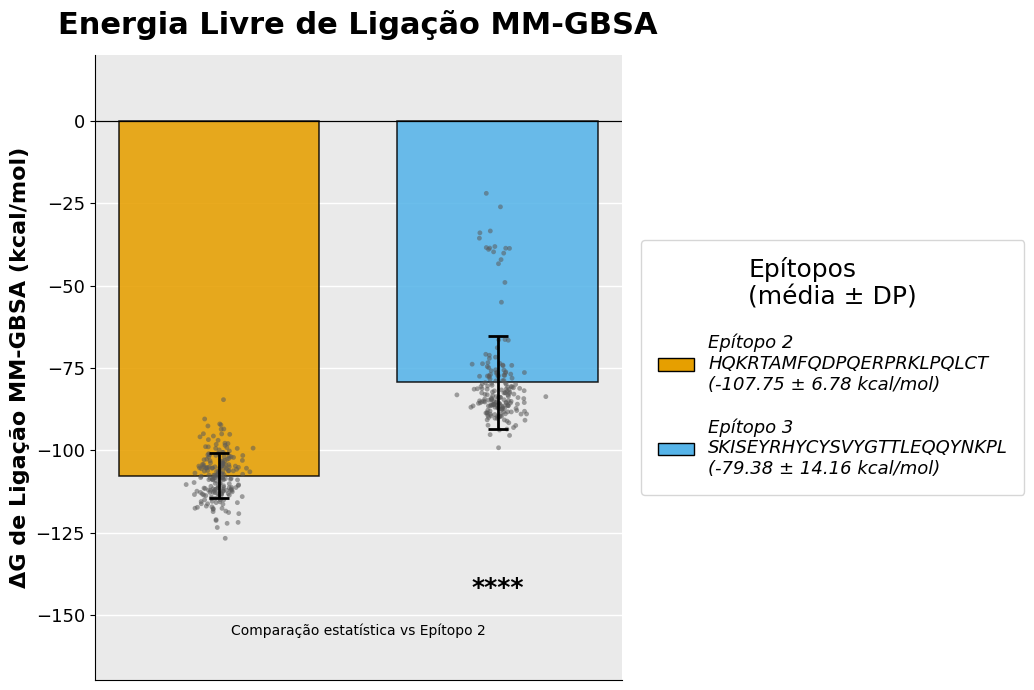

In [ ]:
# ============================================================
# MM-GBSA - Barplot com média ± desvio padrão
# Comparação estatística: Epítopo 3 vs Epítopo 2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Arquivos de entrada e Sequências
# ------------------------------------------------------------

files = {
    "Epítopo 2": "prime_mmgbsa_ultimos20ns_md_400ns_8WO1_conf_epitope_peptide2_hpv16_e6_bcell.csv",
    "Epítopo 3": "prime_mmgbsa_ultimos20ns_md_400ns_8WO1_conf_epitope_peptide3_hpv16_e6_bcell.csv",
}

epitopes_order = [
    "Epítopo 2",
    "Epítopo 3",
]

epitopes_seqs = {
    "Epítopo 2": "HQKRTAMFQDPQERPRKLPQLCT",
    "Epítopo 3": "SKISEYRHYCYSVYGTTLEQQYNKPL",
}

# ------------------------------------------------------------
# 2. Cores das barras por epítopo
# ------------------------------------------------------------

epitopes_colors = {
    "Epítopo 2": "#E69F00",
    "Epítopo 3": "#56B4E9",
}

# ------------------------------------------------------------
# 3. Ler e organizar os dados
# ------------------------------------------------------------

all_data = []

for epitope, file in files.items():

    df = pd.read_csv(file)

    energy_col = "MMGBSA dG Bind"

    temp = pd.DataFrame({
        "Epitope": epitope,
        "MMGBSA": df[energy_col]
    })

    temp["MMGBSA"] = (
        temp["MMGBSA"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    temp = temp.dropna(subset=["MMGBSA"])

    # Remove valores positivos
    temp = temp[temp["MMGBSA"] < 0]

    all_data.append(temp)

data = pd.concat(all_data, ignore_index=True)

data["Epitope"] = pd.Categorical(
    data["Epitope"],
    categories=epitopes_order,
    ordered=True
)

# ------------------------------------------------------------
# 4. Média e desvio padrão
# ------------------------------------------------------------

summary = (
    data
    .groupby("Epitope", observed=True)
    .agg(
        n=("MMGBSA", "count"),
        mean=("MMGBSA", "mean"),
        sd=("MMGBSA", "std")
    )
    .reset_index()
)

print("\nResumo MM-GBSA:")
print(summary)

# ------------------------------------------------------------
# 5. Teste estatístico contra Epítopo 2
# ------------------------------------------------------------

reference = "Epítopo 2"
reference_values = data.loc[data["Epitope"] == reference, "MMGBSA"]

stat_results = []

for epitope in epitopes_order:

    if epitope == reference:
        continue

    test_values = data.loc[data["Epitope"] == epitope, "MMGBSA"]

    stat, p_value = ttest_ind(
        reference_values,
        test_values,
        equal_var=False,
        nan_policy="omit"
    )

    stat_results.append({
        "Epitope": epitope,
        "Comparison": f"{epitope} vs {reference}",
        "t_statistic": stat,
        "p_value": p_value
    })

stats_df = pd.DataFrame(stat_results)

stats_df["p_adjusted"] = multipletests(
    stats_df["p_value"],
    method="fdr_bh"
)[1]

def significance_label(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

stats_df["significance"] = stats_df["p_adjusted"].apply(significance_label)

print(f"\nComparações estatísticas contra {reference}:")
print(stats_df)

# ------------------------------------------------------------
# 6. Construção do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 7))

# Fundo cinza
fig.patch.set_facecolor("white")
ax.set_facecolor("#EAEAEA")

x = np.arange(len(epitopes_order))

summary_indexed = summary.set_index("Epitope").loc[epitopes_order]

means = summary_indexed["mean"]
sds = summary_indexed["sd"]

bar_colors = [epitopes_colors[ep] for ep in epitopes_order]

ax.bar(
    x,
    means,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.1,
    width=0.72,
    alpha=0.88,
    zorder=2
)

# ------------------------------------------------------------
# 7. Pontos experimentais uniformes e suaves
# ------------------------------------------------------------

np.random.seed(42)

point_color = "#5A5A5A"

for i, epitope in enumerate(epitopes_order):

    values = data.loc[data["Epitope"] == epitope, "MMGBSA"].values

    jitter = np.random.normal(
        loc=0,
        scale=0.045,
        size=len(values)
    )

    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        color=point_color,
        edgecolor="none",
        alpha=0.55,
        s=12,
        zorder=3
    )

# ------------------------------------------------------------
# 8. Barras de erro visíveis
# ------------------------------------------------------------

ax.errorbar(
    x,
    means,
    yerr=sds,
    fmt="none",
    ecolor="black",
    elinewidth=2.0,
    capsize=7,
    capthick=2.0,
    zorder=6
)

# ------------------------------------------------------------
# 9. Asteriscos de significância na parte inferior
# ------------------------------------------------------------

lowest_value = min(data["MMGBSA"].min(), (means - sds).min())

significance_y = lowest_value - 15
label_y = significance_y - 13

for _, row in stats_df.iterrows():

    epitope = row["Epitope"]
    significance = row["significance"]

    i = epitopes_order.index(epitope)

    ax.text(
        i,
        significance_y,
        significance,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="black"
    )

ax.text(
    0.5,
    label_y,
    f"Comparação estatística vs {reference}",
    ha="center",
    va="center",
    fontsize=10,
    color="black"
)

# ------------------------------------------------------------
# 10. Personalização do gráfico
# ------------------------------------------------------------

ax.set_title(
    "Energia Livre de Ligação MM-GBSA",
    fontsize=22,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "ΔG de Ligação MM-GBSA (kcal/mol)",
    fontsize=16,
    fontweight="bold"
)

# Remover eixo X
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="x", bottom=False)

ax.tick_params(axis="y", labelsize=13)

# Linha em zero
ax.axhline(
    0,
    color="black",
    linewidth=0.9,
    zorder=5
)

# Grade branca sobre fundo cinza
ax.grid(
    axis="y",
    color="white",
    linewidth=1.0,
    linestyle="-",
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 11. Legenda com sequência e média ± desvio padrão
# ------------------------------------------------------------

legend_elements = []

for ep in epitopes_order:

    mean_value = summary_indexed.loc[ep, "mean"]
    sd_value = summary_indexed.loc[ep, "sd"]
    seq = epitopes_seqs[ep]

    # Adicionado a sequência de aminoácidos à quebra de linha
    label = f"{ep}\n{seq}\n({mean_value:.2f} ± {sd_value:.2f} kcal/mol)"

    legend_elements.append(
        Patch(
            facecolor=epitopes_colors[ep],
            edgecolor="black",
            label=label
        )
    )

legend = ax.legend(
    handles=legend_elements,
    title="Epítopos\n(média ± DP)",
    title_fontsize=18,
    fontsize=13, # Fonte levemente reduzida para acomodar sequências longas
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.35,
    borderpad=0.9
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

# Ajuste do eixo Y
y_min = label_y - 15
y_max = 20

ax.set_ylim(y_min, y_max)

plt.tight_layout()

# ------------------------------------------------------------
# 12. Salvar figura
# ------------------------------------------------------------

plt.savefig(
    "MMGBSA_barplot_epitopos_2e3_PT.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.savefig(
    "MMGBSA_barplot_epitopos_2e3_PT.pdf",
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 13. Salvar tabelas
# ------------------------------------------------------------

summary.to_csv(
    "MMGBSA_summary_media_dp_2e3_PT.csv",
    index=False
)

stats_df.to_csv(
    "MMGBSA_estatistica_Epitopo3_vs_Epitopo2_PT.csv",
    index=False
)

Por causa de uma conformação diferente no docking, a decomposição de energia da dinâmica molecular de 2 epítopos identícos (Epítopo 1 e 2) ocasiou em diferentes valores de afinidade complemente indistiguíveis. Indicando a natureza estocástica da dinâmica molecular.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2051/3482946279.py:16: SyntaxWarning: invalid escape sequence '\m'
  label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
/tmp/ipykernel_2051/3482946279.py:16: SyntaxWarning: invalid escape sequence '\p'
  label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
/tmp/ipykernel_205

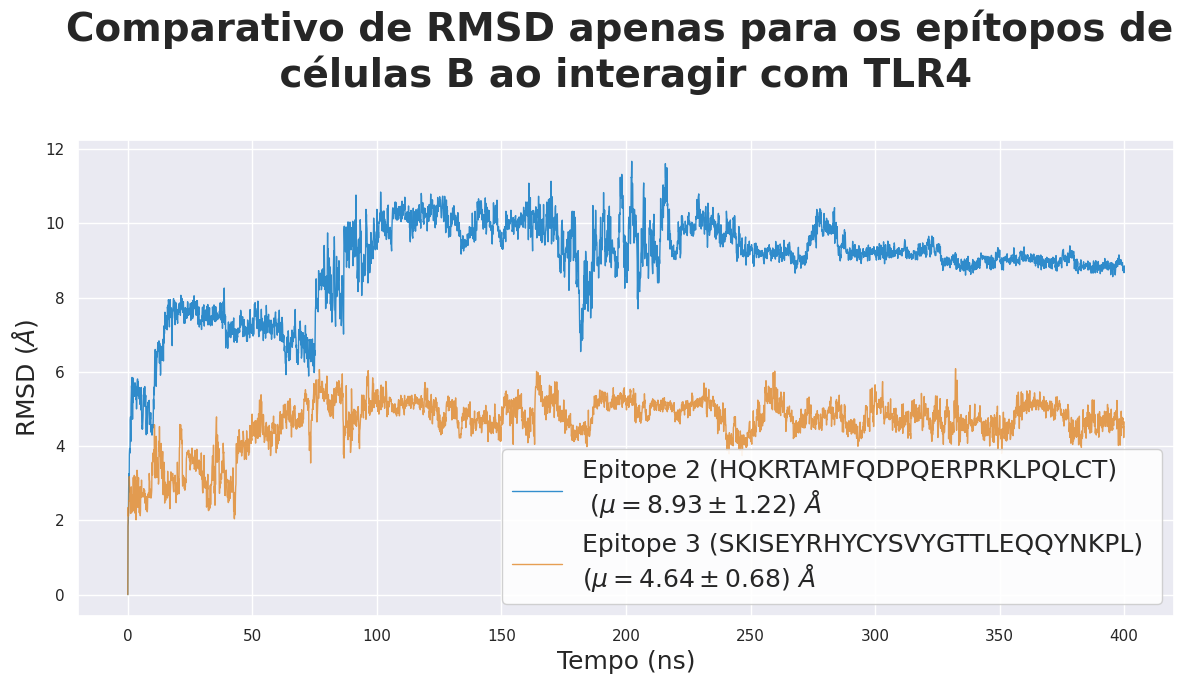

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df_epitope2 = pd.read_csv('rmsd_apenas_epitope2_md_400ns_com_TLR4.csv')
df_epitope3 = pd.read_csv('rmsd_apenas_epitope3_md_400ns_com_TLR4.csv')

# 2. Calcular estatísticas (Média e Desvio Padrão)
# Usando iloc[:, 2] para pegar a coluna de RMSD (3ª coluna)
mean_ep2, std_ep2 = df_epitope2.iloc[:, 2].mean(), df_epitope2.iloc[:, 2].std()
mean_ep3, std_ep3 = df_epitope3.iloc[:, 2].mean(), df_epitope3.iloc[:, 2].std()

# 3. Criar textos para a legenda
# \mu é o símbolo grego para média
label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (SKISEYRHYCYSVYGTTLEQQYNKPL) \n($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas
# Eixo X é sempre 'Time (ns)'
plt.plot(df_epitope2['Time (ns)'], df_epitope2.iloc[:, 2],
         color='#0073C2', label=label_ep2, linewidth=1, alpha=0.8)

plt.plot(df_epitope3['Time (ns)'], df_epitope3.iloc[:, 2],
         color='#E18727', label=label_ep3, linewidth=1, alpha=0.8)

# 6. Estilização final
plt.title('Comparativo de RMSD apenas para os epítopos de \n células B ao interagir com TLR4 \n', fontsize=28, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'RMSD ($\AA$)', fontsize=18)
plt.legend(fontsize=18, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rmsd_comparativo_apenas_epitopo_celula_b.png', dpi=600)
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2051/2707778504.py:16: SyntaxWarning: invalid escape sequence '\m'
  label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
/tmp/ipykernel_2051/2707778504.py:16: SyntaxWarning: invalid escape sequence '\p'
  label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
/tmp/ipykernel_205

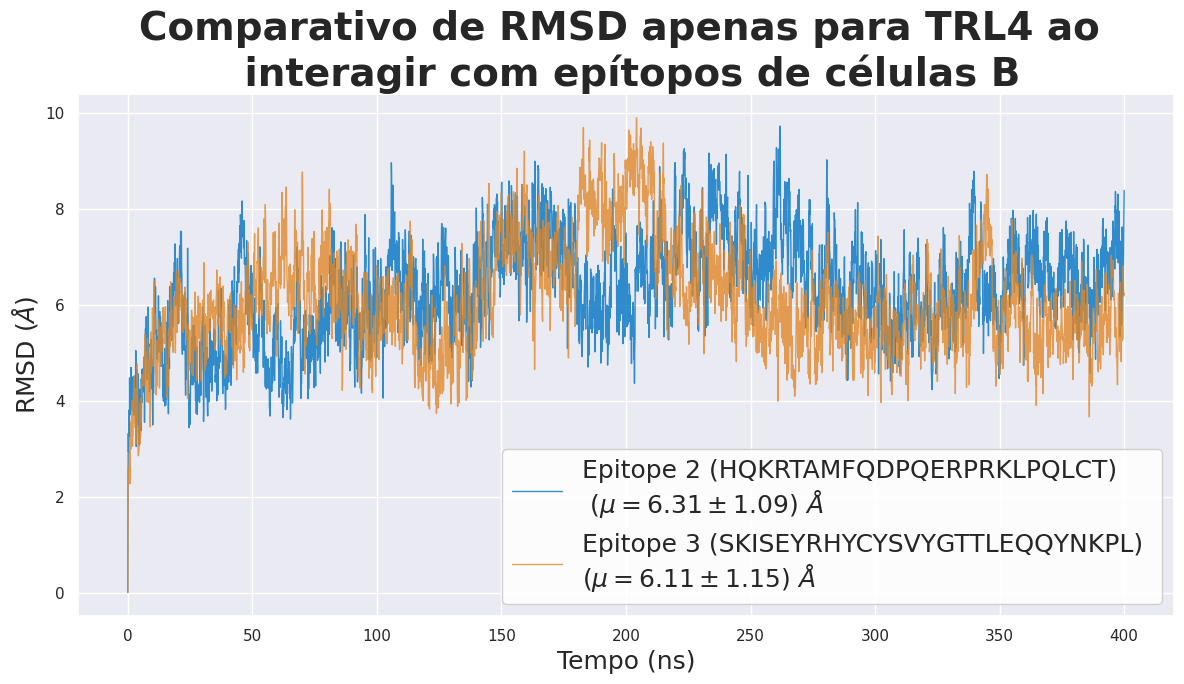

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df_epitope2 = pd.read_csv('rmsd_apenas_TLR4_md_400ns_epitope2.csv')
df_epitope3 = pd.read_csv('rmsd_apenas_TLR4_md_400ns_epitope3.csv')

# 2. Calcular estatísticas (Média e Desvio Padrão)
# Usando iloc[:, 2] para pegar a coluna de RMSD (3ª coluna)
mean_ep2, std_ep2 = df_epitope2.iloc[:, 2].mean(), df_epitope2.iloc[:, 2].std()
mean_ep3, std_ep3 = df_epitope3.iloc[:, 2].mean(), df_epitope3.iloc[:, 2].std()

# 3. Criar textos para a legenda
# \mu é o símbolo grego para média
label_ep2 = f'Epitope 2 (HQKRTAMFQDPQERPRKLPQLCT) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (SKISEYRHYCYSVYGTTLEQQYNKPL) \n($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas
# Eixo X é sempre 'Time (ns)'
plt.plot(df_epitope2['Time (ns)'], df_epitope2.iloc[:, 2],
         color='#0073C2', label=label_ep2, linewidth=1, alpha=0.8)

plt.plot(df_epitope3['Time (ns)'], df_epitope3.iloc[:, 2],
         color='#E18727', label=label_ep3, linewidth=1, alpha=0.8)

# 6. Estilização final
plt.title('Comparativo de RMSD apenas para TRL4 ao \n interagir com epítopos de células B', fontsize=28, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'RMSD ($\AA$)', fontsize=18)
plt.legend(fontsize=18, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rmsd_comparativo_apenas_TLR4_celula_b.png', dpi=600)
plt.show()

# Análise de epítopos de células T


Melhor Afinidade de Ligação (MM-GBSA) por Epítopo (Ordenado):
            Sequence  Best_MMGBSA
Epitope                          
Epítopo 1  KFYSKISEY       -72.90
Epítopo 8  RPRKLPQLC       -63.96
Epítopo 7  QQLLRREVY       -52.94
Epítopo 4  FYSKISEYR       -44.68
Epítopo 3  TTLEQQYNK       -44.56
Epítopo 2  KLPQLCTEL       -37.24
Epítopo 5  ISEYRHYCY       -31.20
Epítopo 6  IVYRDGNPY       -19.43


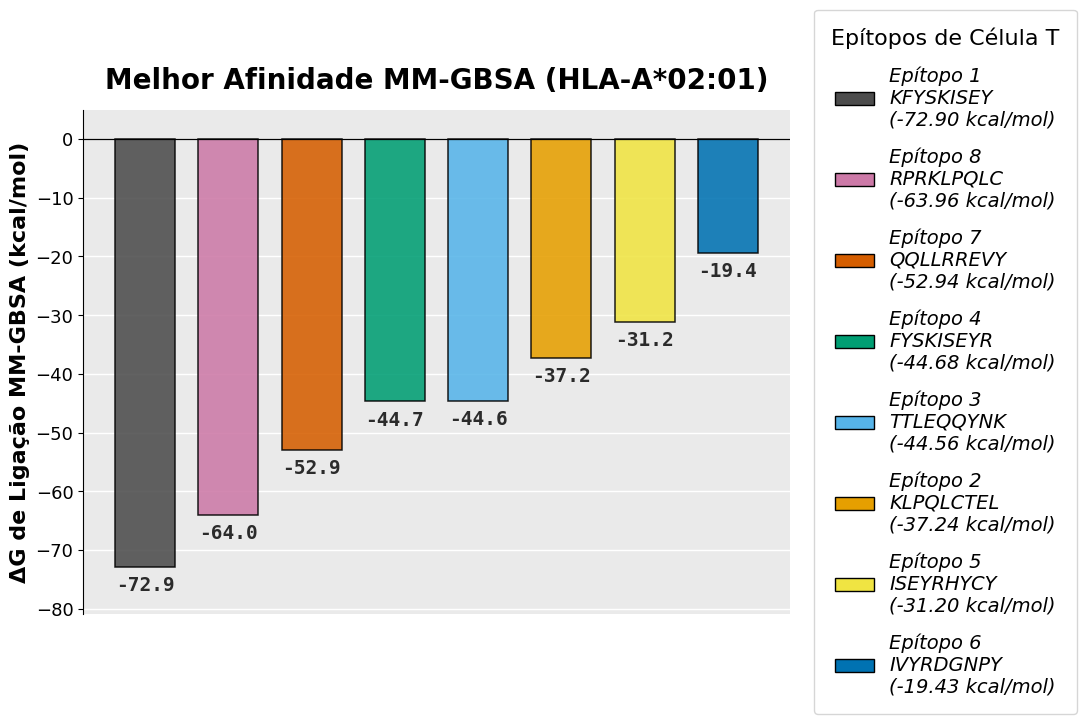

In [4]:
# ============================================================
# MM-GBSA - Barplot da Melhor Afinidade (Menor Energia)
# Interação: Epítopos de Células T vs HLA-A*02:01
# Ordem decrescente de afinidade (mais negativo para menos negativo)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# ------------------------------------------------------------
# 1. Arquivos de entrada e Sequências
# ------------------------------------------------------------

files = {
    "Epítopo 1": "prime_mmgbsa_docking_conf_epitope_kfyskisey_com_4U6Y_HLA-A_02_01-out1.csv",
    "Epítopo 2": "prime_mmgbsa_docking_epitope_klpqlctel_com_4U6Y_HLA-A_0201-out1.csv",
    "Epítopo 3": "prime_mmgbsa_docking_epitope_ttleqqynk_com_4U6Y_HLA-A_2_02-out1.csv",
    "Epítopo 4": "prime_mmgbsa_docking_fold_epitope_fyskiseyr_model_2_com_4U6Y_HLA-A_02_01-out.csv",
    "Epítopo 5": "prime_mmgbsa_docking_fold_epitope_iseyrhycy_model_3_com_4U6Y_HLA-A_02_01-out.csv",
    "Epítopo 6": "prime_mmgbsa_docking_fold_epitope_ivyrdgnpy_model_2_com_4U6Y_HLA-A_02_01-out1.csv",
    "Epítopo 7": "prime_mmgbsa_docking_fold_epitope_qqllrrevy_model_0_com_4U6Y_HLA-A_02_01_pose_14-out1.csv",
    "Epítopo 8": "prime_mmgbsa_docking_fold_epitope_rprklpqlc_model_3_com_4U6Y_HLA-A_02_01-out.csv",
}

# Extração automática da sequência a partir do nome do arquivo
epitopes_seqs = {}
for ep, filename in files.items():
    match = re.search(r'epitope_([a-zA-Z]+)_', filename)
    if match:
        epitopes_seqs[ep] = match.group(1).upper()
    else:
        epitopes_seqs[ep] = "Desconhecido"

# ------------------------------------------------------------
# 2. Cores das barras por epítopo
# ------------------------------------------------------------

epitopes_colors = {
    "Epítopo 1": "#4C4C4C",
    "Epítopo 2": "#E69F00",
    "Epítopo 3": "#56B4E9",
    "Epítopo 4": "#009E73",
    "Epítopo 5": "#F0E442",
    "Epítopo 6": "#0072B2",
    "Epítopo 7": "#D55E00",
    "Epítopo 8": "#CC79A7",
}

# ------------------------------------------------------------
# 3. Ler dados e extrair apenas a MELHOR conformação
# ------------------------------------------------------------

best_affinities = []

for epitope, file in files.items():

    df = pd.read_csv(file)
    energy_col = "MMGBSA dG Bind"

    # Tratamento da coluna para numérico
    valores = (
        df[energy_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
        .dropna()
    )

    # Pega o menor valor (mais negativo = melhor afinidade)
    melhor_afinidade = valores.min()

    best_affinities.append({
        "Epitope": epitope,
        "Sequence": epitopes_seqs[epitope],
        "Best_MMGBSA": melhor_afinidade
    })

summary = pd.DataFrame(best_affinities)

# Ordenar do mais negativo (maior afinidade) para o menos negativo
summary = summary.sort_values(by="Best_MMGBSA", ascending=True)
summary = summary.set_index("Epitope")

print("\nMelhor Afinidade de Ligação (MM-GBSA) por Epítopo (Ordenado):")
print(summary)

# ------------------------------------------------------------
# 4. Construção do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Fundo cinza
fig.patch.set_facecolor("white")
ax.set_facecolor("#EAEAEA")

# Como os dados foram ordenados, o eixo X e as cores devem seguir o novo index
epitopes_order_sorted = summary.index.tolist()
x = np.arange(len(epitopes_order_sorted))
y_values = summary["Best_MMGBSA"]

bar_colors = [epitopes_colors[ep] for ep in epitopes_order_sorted]

bars = ax.bar(
    x,
    y_values,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.1,
    width=0.72,
    alpha=0.88,
    zorder=2
)

# ------------------------------------------------------------
# 5. Adicionar o valor exato isolado abaixo de cada barra
# ------------------------------------------------------------

for bar in bars:
    height = bar.get_height()
    # Posição Y do texto abaixo da barra, alinhado pelo topo (top) do texto
    # Mudei a fonte para monospace para diferenciar do resto do gráfico
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height - 1.5,
        f"{height:.1f}",
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        fontfamily='monospace',
        color='#2B2B2B',
        zorder=3
    )

# ------------------------------------------------------------
# 6. Personalização do gráfico
# ------------------------------------------------------------

ax.set_title(
    "Melhor Afinidade MM-GBSA (HLA-A*02:01)",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "ΔG de Ligação MM-GBSA (kcal/mol)",
    fontsize=16,
    fontweight="bold"
)

# Remover eixo X numérico/textual da base
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", labelsize=13)

# Linha principal no zero
ax.axhline(0, color="black", linewidth=0.9, zorder=5)

# Grade branca sobre fundo cinza
ax.grid(axis="y", color="white", linewidth=1.0, linestyle="-", zorder=1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# ------------------------------------------------------------
# 7. Legenda com Sequência e Valor (Na mesma ordem das barras)
# ------------------------------------------------------------

legend_elements = []

for ep in epitopes_order_sorted:
    valor = summary.loc[ep, "Best_MMGBSA"]
    seq = summary.loc[ep, "Sequence"]

    label = f"{ep}\n{seq}\n({valor:.2f} kcal/mol)"

    legend_elements.append(
        Patch(
            facecolor=epitopes_colors[ep],
            edgecolor="black",
            label=label
        )
    )

legend = ax.legend(
    handles=legend_elements,
    title="Epítopos de Célula T",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=0.9,
    borderpad=0.9
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

# Ajuste automático do limite Y para comportar os novos textos mais para baixo
menor_y = y_values.min()
ax.set_ylim(menor_y - 8, 5)

plt.tight_layout()

# ------------------------------------------------------------
# 8. Salvar figura e tabela
# ------------------------------------------------------------

plt.savefig(
    "MMGBSA_barplot_best_affinity_sorted_PT.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.savefig(
    "MMGBSA_barplot_best_affinity_sorted_PT.pdf",
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

summary.to_csv(
    "MMGBSA_melhor_afinidade_ordenada_PT.csv",
    index=True
)

# Análise de epítopos de células-T com MHC HLA-A*02:01


Resumo MM-GBSA:
     Epitope    n       mean         sd
0  Epitope 1  194 -39.141546   9.643405
1  Epitope 2  189 -34.142011  12.198116
2  Epitope 3  201 -55.549005   8.749633

Comparações estatísticas contra Epitope 3:
     Epitope              Comparison  t_statistic       p_value    p_adjusted  \
0  Epitope 1  Epitope 1 vs Epitope 3   -17.690221  1.018261e-51  1.018261e-51   
1  Epitope 2  Epitope 2 vs Epitope 3   -19.806472  1.452694e-58  2.905388e-58   

  significance  
0         ****  
1         ****  


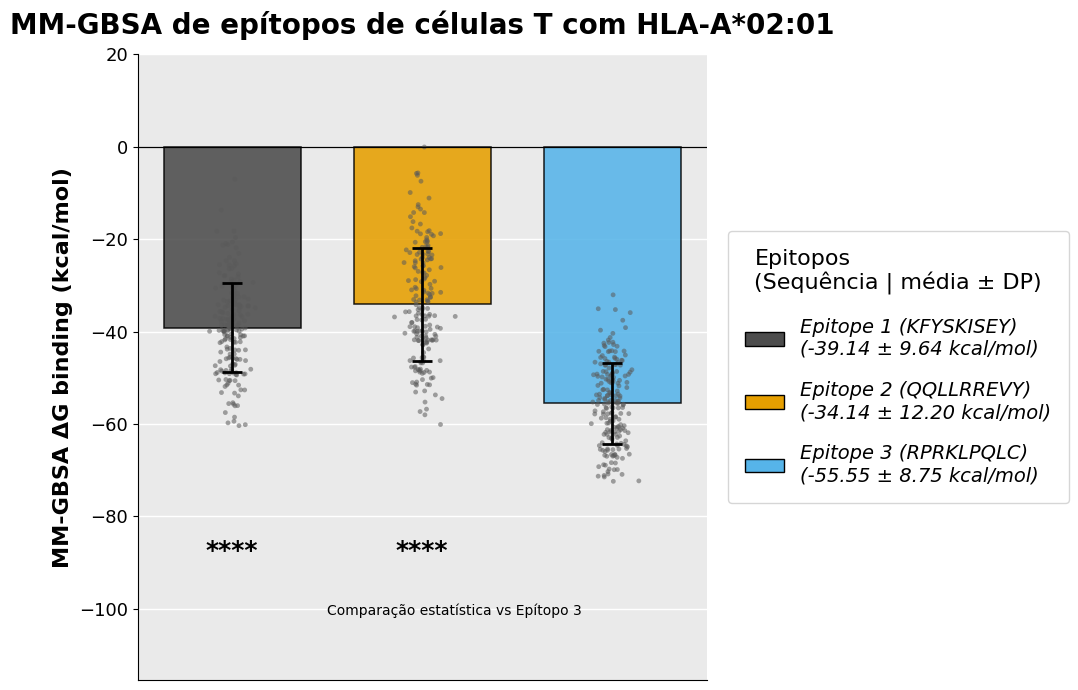

In [ ]:
# ============================================================
# MM-GBSA - Barplot com média ± desvio padrão
# Comparação estatística contra Epitope 3
#
# Ajustes:
# - fundo cinza no gráfico;
# - cada epítopo com uma cor diferente;
# - legenda no lugar do eixo X;
# - legenda com sequência, média ± desvio padrão abaixo do nome;
# - remoção de valores positivos;
# - pontos experimentais uniformes e suaves;
# - barra de erro visível;
# - asteriscos de significância na parte inferior;
# - sem barras horizontais de comparação estatística;
# - significância sempre calculada contra Epitope 3.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Arquivos de entrada e Sequências
# ------------------------------------------------------------

files = {
    "Epitope 1": "prime_mmgbsa_ultimos20ns_md400ns_complexo_4U6Y_HLA-A_02_01_epitope_kfyskisey_conf7-out1.csv",
    "Epitope 2": "prime_mmgbsa_ultimos20ns_md400ns_complexo_epitope_qqllrrevy_conf10_4U6Y_HLA-A_02_01-out1.csv",
    "Epitope 3": "prime_mmgbsa_ultimos20ns_md400ns_complexo_epitope_rprklpqlc_conf8_com_4U6Y_HLA-A_02_01-out1.csv",
}

epitopes_order = [
    "Epitope 1",
    "Epitope 2",
    "Epitope 3",
]

epitopes_seq = {
    "Epitope 1": "KFYSKISEY",
    "Epitope 2": "QQLLRREVY",
    "Epitope 3": "RPRKLPQLC",
}

# ------------------------------------------------------------
# 2. Cores das barras por epítopo
# ------------------------------------------------------------

epitopes_colors = {
    "Epitope 1": "#4C4C4C",
    "Epitope 2": "#E69F00",
    "Epitope 3": "#56B4E9",
}

# ------------------------------------------------------------
# 3. Ler e organizar os dados
# ------------------------------------------------------------

all_data = []

for epitope, file in files.items():

    df = pd.read_csv(file)

    energy_col = "MMGBSA dG Bind"

    temp = pd.DataFrame({
        "Epitope": epitope,
        "MMGBSA": df[energy_col]
    })

    temp["MMGBSA"] = (
        temp["MMGBSA"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    temp = temp.dropna(subset=["MMGBSA"])

    # Remove valores positivos
    temp = temp[temp["MMGBSA"] < 0]

    all_data.append(temp)

data = pd.concat(all_data, ignore_index=True)

data["Epitope"] = pd.Categorical(
    data["Epitope"],
    categories=epitopes_order,
    ordered=True
)

# ------------------------------------------------------------
# 4. Média e desvio padrão
# ------------------------------------------------------------

summary = (
    data
    .groupby("Epitope", observed=True)
    .agg(
        n=("MMGBSA", "count"),
        mean=("MMGBSA", "mean"),
        sd=("MMGBSA", "std")
    )
    .reset_index()
)

print("\nResumo MM-GBSA:")
print(summary)

# ------------------------------------------------------------
# 5. Teste estatístico contra Epitope 3
# ------------------------------------------------------------

reference = "Epitope 3"
reference_values = data.loc[data["Epitope"] == reference, "MMGBSA"]

stat_results = []

for epitope in epitopes_order:

    if epitope == reference:
        continue

    test_values = data.loc[data["Epitope"] == epitope, "MMGBSA"]

    stat, p_value = ttest_ind(
        reference_values,
        test_values,
        equal_var=False,
        nan_policy="omit"
    )

    stat_results.append({
        "Epitope": epitope,
        "Comparison": f"{epitope} vs {reference}",
        "t_statistic": stat,
        "p_value": p_value
    })

stats_df = pd.DataFrame(stat_results)

stats_df["p_adjusted"] = multipletests(
    stats_df["p_value"],
    method="fdr_bh"
)[1]

def significance_label(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

stats_df["significance"] = stats_df["p_adjusted"].apply(significance_label)

print("\nComparações estatísticas contra Epitope 3:")
print(stats_df)

# ------------------------------------------------------------
# 6. Construção do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 7))

# Fundo cinza
fig.patch.set_facecolor("white")
ax.set_facecolor("#EAEAEA")

x = np.arange(len(epitopes_order))

summary_indexed = summary.set_index("Epitope").loc[epitopes_order]

means = summary_indexed["mean"]
sds = summary_indexed["sd"]

bar_colors = [epitopes_colors[ep] for ep in epitopes_order]

ax.bar(
    x,
    means,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.1,
    width=0.72,
    alpha=0.88,
    zorder=2
)

# ------------------------------------------------------------
# 7. Pontos experimentais uniformes e suaves
# ------------------------------------------------------------

np.random.seed(42)

point_color = "#5A5A5A"

for i, epitope in enumerate(epitopes_order):

    values = data.loc[data["Epitope"] == epitope, "MMGBSA"].values

    jitter = np.random.normal(
        loc=0,
        scale=0.045,
        size=len(values)
    )

    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        color=point_color,
        edgecolor="none",
        alpha=0.55,
        s=12,
        zorder=3
    )

# ------------------------------------------------------------
# 8. Barras de erro visíveis
# ------------------------------------------------------------

ax.errorbar(
    x,
    means,
    yerr=sds,
    fmt="none",
    ecolor="black",
    elinewidth=2.0,
    capsize=7,
    capthick=2.0,
    zorder=6
)

# ------------------------------------------------------------
# 9. Asteriscos de significância na parte inferior
# Sempre em comparação ao Epitope 3
# ------------------------------------------------------------

lowest_value = min(data["MMGBSA"].min(), (means - sds).min())

significance_y = lowest_value - 15
label_y = significance_y - 13

for _, row in stats_df.iterrows():

    epitope = row["Epitope"]
    significance = row["significance"]

    i = epitopes_order.index(epitope)

    ax.text(
        i,
        significance_y,
        significance,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="black"
    )

ax.text(
    0.5,
    label_y,
    "Comparação estatística vs Epítopo 3",
    ha="left",
    va="center",
    fontsize=10,
    color="black"
)

# ------------------------------------------------------------
# 10. Personalização do gráfico
# ------------------------------------------------------------

ax.set_title(
    "MM-GBSA de epítopos de células T com HLA-A*02:01",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "MM-GBSA ΔG binding (kcal/mol)",
    fontsize=16,
    fontweight="bold"
)

# Remover eixo X
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="x", bottom=False)

ax.tick_params(axis="y", labelsize=13)

# Linha em zero
ax.axhline(
    0,
    color="black",
    linewidth=0.9,
    zorder=5
)

# Grade branca sobre fundo cinza
ax.grid(
    axis="y",
    color="white",
    linewidth=1.0,
    linestyle="-",
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 11. Legenda com sequência e média ± desvio padrão
# ------------------------------------------------------------

legend_elements = []

for ep in epitopes_order:

    mean_value = summary_indexed.loc[ep, "mean"]
    sd_value = summary_indexed.loc[ep, "sd"]
    seq = epitopes_seq[ep]

    label = f"{ep} ({seq})\n({mean_value:.2f} ± {sd_value:.2f} kcal/mol)"

    legend_elements.append(
        Patch(
            facecolor=epitopes_colors[ep],
            edgecolor="black",
            label=label
        )
    )

legend = ax.legend(
    handles=legend_elements,
    title="Epitopos\n(Sequência | média ± DP)",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.15,
    borderpad=0.9
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

# Ajuste do eixo Y
y_min = label_y - 15
y_max = 20

ax.set_ylim(y_min, y_max)

plt.tight_layout()

# ------------------------------------------------------------
# 12. Salvar figura
# ------------------------------------------------------------

plt.savefig(
    "MMGBSA_barplot_epitopes_gray_background_legend_mean_sd.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.savefig(
    "MMGBSA_barplot_epitopes_gray_background_legend_mean_sd.pdf",
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 13. Salvar tabelas
# ------------------------------------------------------------

summary.to_csv(
    "MMGBSA_summary_mean_sd_filtered_negative.csv",
    index=False
)

stats_df.to_csv(
    "MMGBSA_statistics_vs_Epitope_3_filtered_negative.csv",
    index=False
)

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\A'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/3330635559.py:18: SyntaxWarning: invalid escape sequence '\m'


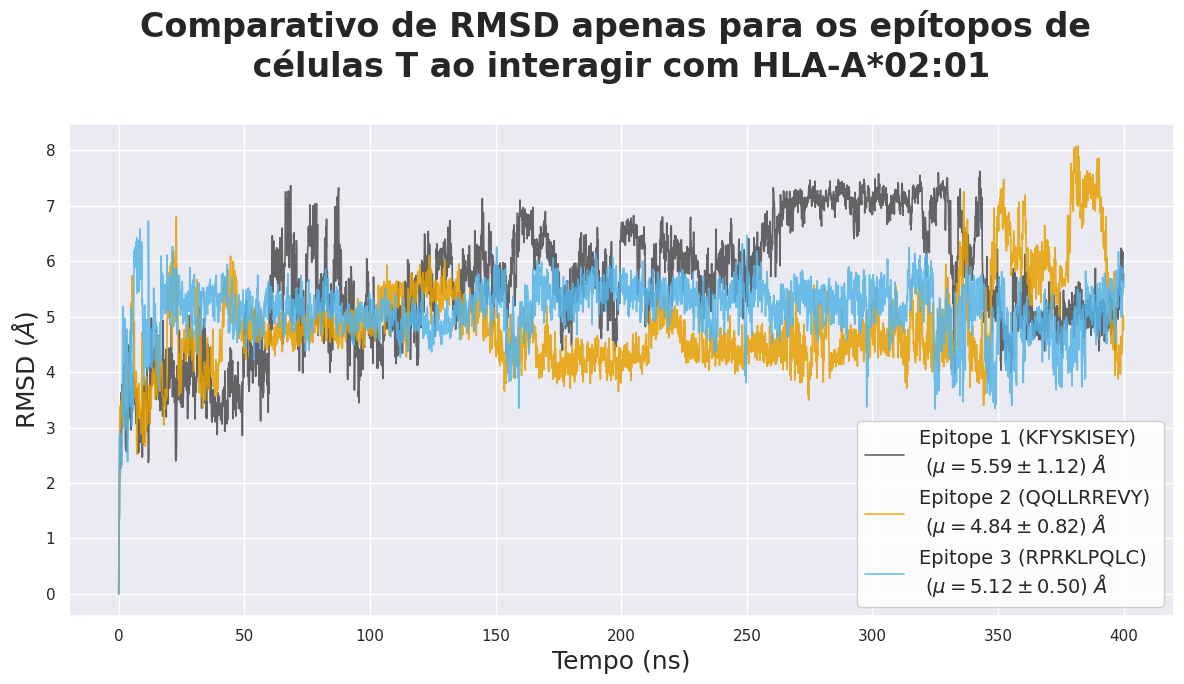

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df_epitope1 = pd.read_csv('rmsd_apenas_epitope_kfyskisey_conf7_com_4U6Y_HLA-A_02_01.csv')
df_epitope2 = pd.read_csv('rmsd_apenas_epitope_qqllrrevy_conf10_com_4U6Y_HLA-A_02_01.csv')
df_epitope3 = pd.read_csv('rmsd_apenas_epitope_rprklpqlc_conf8_com_4U6Y_HLA-A_02_01.csv')

# 2. Calcular estatísticas (Média e Desvio Padrão)
# Usando iloc[:, 2] para pegar a coluna de RMSD (3ª coluna)
mean_ep1, std_ep1 = df_epitope1.iloc[:, 2].mean(), df_epitope1.iloc[:, 2].std()
mean_ep2, std_ep2 = df_epitope2.iloc[:, 2].mean(), df_epitope2.iloc[:, 2].std()
mean_ep3, std_ep3 = df_epitope3.iloc[:, 2].mean(), df_epitope3.iloc[:, 2].std()

# 3. Criar textos para a legenda com as sequências corretas
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas
# Eixo X é sempre 'Time (ns)'
plt.plot(df_epitope1['Time (ns)'], df_epitope1.iloc[:, 2],
         color='#4C4C4C', label=label_ep1, linewidth=1.2, alpha=0.85)

plt.plot(df_epitope2['Time (ns)'], df_epitope2.iloc[:, 2],
         color='#E69F00', label=label_ep2, linewidth=1.2, alpha=0.85)

plt.plot(df_epitope3['Time (ns)'], df_epitope3.iloc[:, 2],
         color='#56B4E9', label=label_ep3, linewidth=1.2, alpha=0.85)

# 6. Estilização final
plt.title('Comparativo de RMSD apenas para os epítopos de \n células T ao interagir com HLA-A*02:01 \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'RMSD ($\AA$)', fontsize=18)

# Ajuste do tamanho da fonte da legenda para acomodar as 3 entradas
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rmsd_comparativo_apenas_epitopo_celula_t_hla.png', dpi=600)
plt.savefig('rmsd_comparativo_apenas_epitopo_celula_t_hla.pdf')
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\A'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/3899129292.py:18: SyntaxWarning: invalid escape sequence '\m'


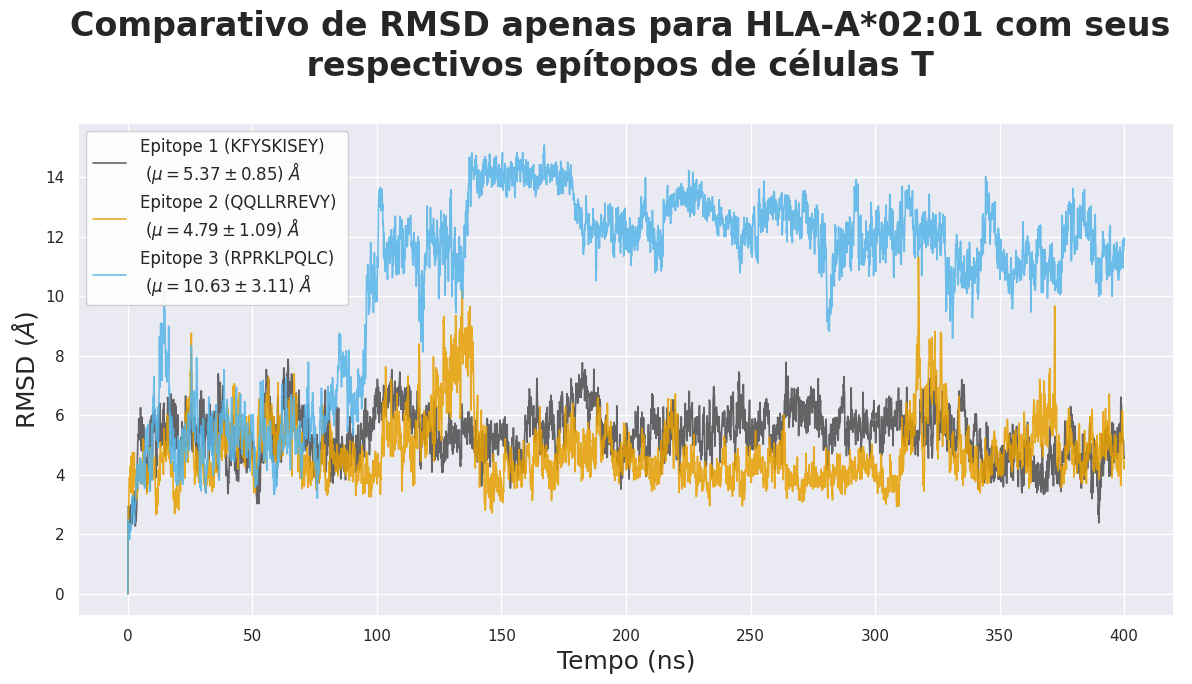

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df_epitope1 = pd.read_csv('rmsd_apenas_4U6Y_HLA-A_02_01_com_epitope_kfyskisey_conf7.csv')
df_epitope2 = pd.read_csv('rmsd_apenas_4U6Y_HLA-A_02_01_com_epitope_qqllrrevy_conf10.csv')
df_epitope3 = pd.read_csv('rmsd_apenas_4U6Y_HLA-A_02_01_com_epitope_rprklpqlc_conf8.csv')

# 2. Calcular estatísticas (Média e Desvio Padrão)
# Usando iloc[:, 2] para pegar a coluna de RMSD (3ª coluna)
mean_ep1, std_ep1 = df_epitope1.iloc[:, 2].mean(), df_epitope1.iloc[:, 2].std()
mean_ep2, std_ep2 = df_epitope2.iloc[:, 2].mean(), df_epitope2.iloc[:, 2].std()
mean_ep3, std_ep3 = df_epitope3.iloc[:, 2].mean(), df_epitope3.iloc[:, 2].std()

# 3. Criar textos para a legenda com as sequências corretas
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas
# Eixo X é sempre 'Time (ns)'
plt.plot(df_epitope1['Time (ns)'], df_epitope1.iloc[:, 2],
         color='#4C4C4C', label=label_ep1, linewidth=1.2, alpha=0.85)

plt.plot(df_epitope2['Time (ns)'], df_epitope2.iloc[:, 2],
         color='#E69F00', label=label_ep2, linewidth=1.2, alpha=0.85)

plt.plot(df_epitope3['Time (ns)'], df_epitope3.iloc[:, 2],
         color='#56B4E9', label=label_ep3, linewidth=1.2, alpha=0.85)

# 6. Estilização final
plt.title('Comparativo de RMSD apenas para HLA-A*02:01 com seus \n respectivos epítopos de células T  \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'RMSD ($\AA$)', fontsize=18)

# Ajuste do tamanho da fonte da legenda para acomodar as 3 entradas
plt.legend(fontsize=12, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rmsd_comparativo_apenas_hla_de_epitopo_celula_T.png', dpi=600)
plt.savefig('rmsd_comparativo_apenas_hla_de_epitopo_celula_T.pdf')
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\A'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\A'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/3329571356.py:24: SyntaxWarning: invalid escape sequence '\m'


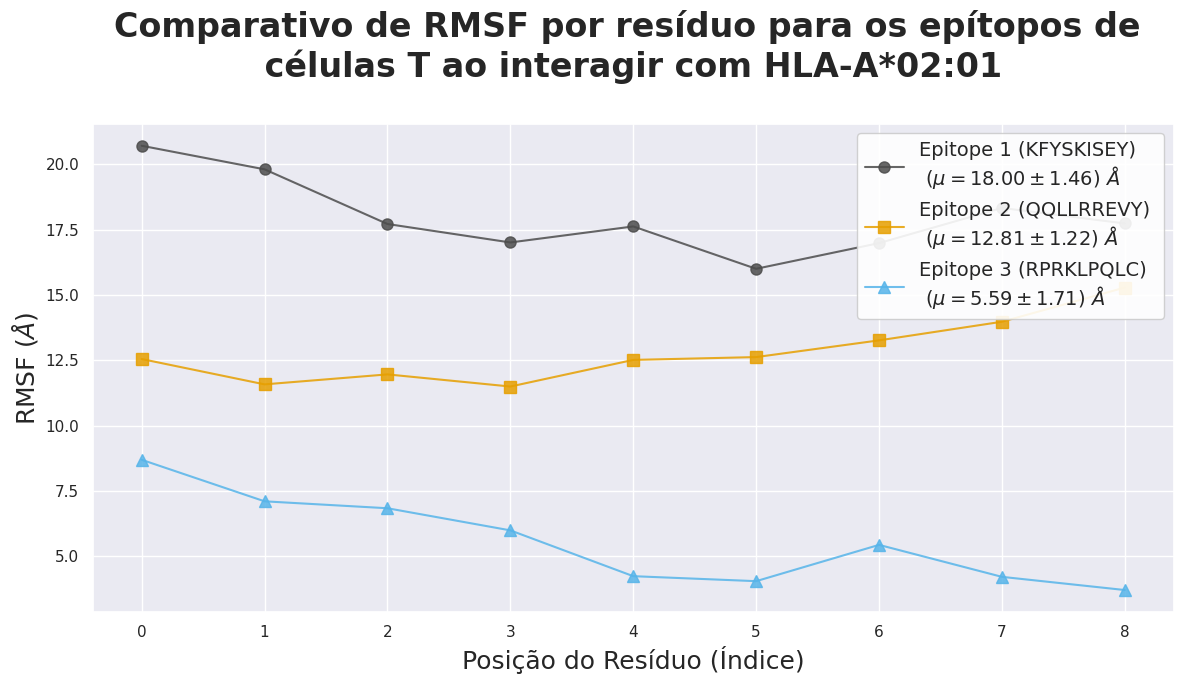

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados de RMSF
df_epitope1 = pd.read_csv('rmsf_apenas_epitope_kfyskisey_conf7_com_4U6Y_HLA-A_02_01.csv')
df_epitope2 = pd.read_csv('rmsf_apenas_epitope_qqllrrevy_conf10_com_4U6Y_HLA-A_02_01.csv')
df_epitope3 = pd.read_csv('rmsf_apenas_epitope_rprklpqlc_conf8_com_4U6Y_HLA-A_02_01.csv')

# --- CORREÇÃO AQUI ---
# A maioria dos arquivos RMSF possui apenas 2 colunas:
# [0] = Índice do Resíduo (Eixo X)
# [1] = Flutuação / RMSF (Eixo Y)
x_col_idx = 0
y_col_idx = 1

# 2. Calcular estatísticas globais da flutuação (Média e Desvio Padrão do RMSF)
mean_ep1, std_ep1 = df_epitope1.iloc[:, y_col_idx].mean(), df_epitope1.iloc[:, y_col_idx].std()
mean_ep2, std_ep2 = df_epitope2.iloc[:, y_col_idx].mean(), df_epitope2.iloc[:, y_col_idx].std()
mean_ep3, std_ep3 = df_epitope3.iloc[:, y_col_idx].mean(), df_epitope3.iloc[:, y_col_idx].std()

# 3. Criar textos para a legenda com as sequências
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas (com marcadores para destacar cada aminoácido)
plt.plot(df_epitope1.iloc[:, x_col_idx], df_epitope1.iloc[:, y_col_idx],
         color='#4C4C4C', marker='o', markersize=8, label=label_ep1, linewidth=1.5, alpha=0.85)

plt.plot(df_epitope2.iloc[:, x_col_idx], df_epitope2.iloc[:, y_col_idx],
         color='#E69F00', marker='s', markersize=8, label=label_ep2, linewidth=1.5, alpha=0.85)

plt.plot(df_epitope3.iloc[:, x_col_idx], df_epitope3.iloc[:, y_col_idx],
         color='#56B4E9', marker='^', markersize=8, label=label_ep3, linewidth=1.5, alpha=0.85)

# 6. Estilização final
plt.title('Comparativo de RMSF por resíduo para os epítopos de \n células T ao interagir com HLA-A*02:01 \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Posição do Resíduo (Índice)', fontsize=18)
plt.ylabel(r'RMSF ($\AA$)', fontsize=18)

# Ajuste da legenda
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9, loc='upper right')

# Forçar o eixo X a exibir apenas números inteiros
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('rmsf_comparativo_apenas_epitopo_celula_t_hla.png', dpi=600)
plt.savefig('rmsf_comparativo_apenas_epitopo_celula_t_hla.pdf')
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/826976052.py:22: SyntaxWarning: invalid escape sequence '\m'
 

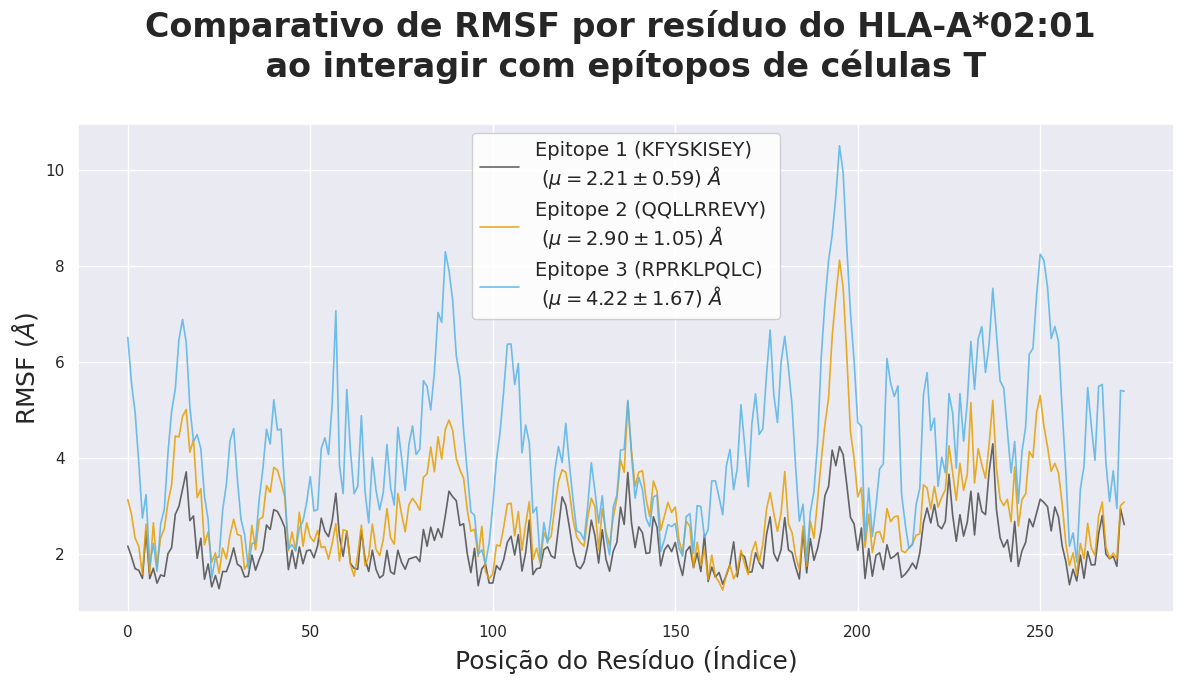

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados de RMSF (agora referentes ao receptor HLA-A*02:01)
df_hla_ep1 = pd.read_csv('rmsf_apenas_4U6Y_HLA-A_02_01_com_epitope_kfyskisey_conf7.csv')
df_hla_ep2 = pd.read_csv('rmsf_apenas_4U6Y_HLA-A_02_01_com_epitope_qqllrrevy_conf10.csv')
df_hla_ep3 = pd.read_csv('rmsf_apenas_4U6Y_HLA-A_02_01_com_epitope_rprklpqlc_conf8.csv')

# [0] = Índice do Resíduo (Eixo X)
# [1] = Flutuação / RMSF (Eixo Y)
x_col_idx = 0
y_col_idx = 1

# 2. Calcular estatísticas globais da flutuação (Média e Desvio Padrão do RMSF)
mean_ep1, std_ep1 = df_hla_ep1.iloc[:, y_col_idx].mean(), df_hla_ep1.iloc[:, y_col_idx].std()
mean_ep2, std_ep2 = df_hla_ep2.iloc[:, y_col_idx].mean(), df_hla_ep2.iloc[:, y_col_idx].std()
mean_ep3, std_ep3 = df_hla_ep3.iloc[:, y_col_idx].mean(), df_hla_ep3.iloc[:, y_col_idx].std()

# 3. Criar textos para a legenda indicando a presença do respectivo epítopo
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas
# Sem marcadores para evitar poluição visual, já que o HLA possui muitos resíduos
plt.plot(df_hla_ep1.iloc[:, x_col_idx], df_hla_ep1.iloc[:, y_col_idx],
         color='#4C4C4C', label=label_ep1, linewidth=1.2, alpha=0.85)

plt.plot(df_hla_ep2.iloc[:, x_col_idx], df_hla_ep2.iloc[:, y_col_idx],
         color='#E69F00', label=label_ep2, linewidth=1.2, alpha=0.85)

plt.plot(df_hla_ep3.iloc[:, x_col_idx], df_hla_ep3.iloc[:, y_col_idx],
         color='#56B4E9', label=label_ep3, linewidth=1.2, alpha=0.85)

# 6. Estilização final
plt.title('Comparativo de RMSF por resíduo do HLA-A*02:01 \n ao interagir com epítopos de células T \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Posição do Resíduo (Índice)', fontsize=18)
plt.ylabel(r'RMSF ($\AA$)', fontsize=18)

# Ajuste da legenda (pode alterar loc para 'best' se 'upper right' cobrir algum pico)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rmsf_comparativo_receptor_hla.png', dpi=600)
plt.savefig('rmsf_comparativo_receptor_hla.pdf')
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\A'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/3945128034.py:27: SyntaxWarning: invalid escape sequence '\m'


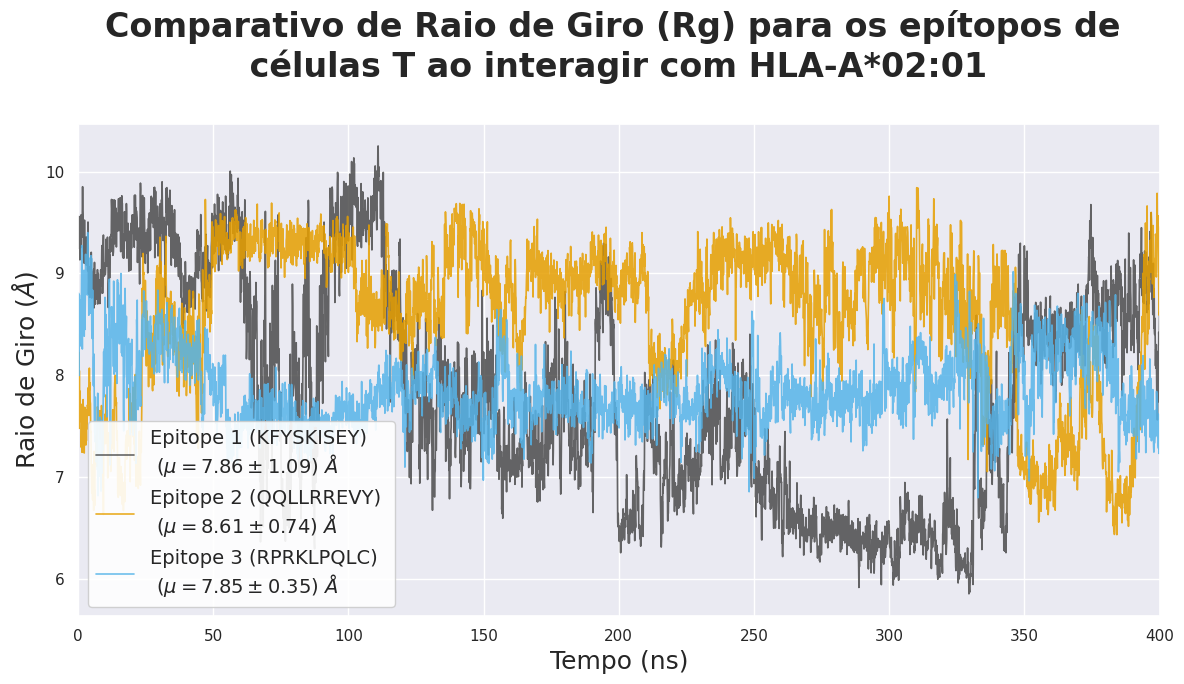

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados de Raio de Giro (Rg)
df_ep1 = pd.read_csv('rgyr_apenas_epitope_kfyskisey_conf7_com_4U6Y_HLA-A_02_01.csv')
df_ep2 = pd.read_csv('rgyr_apenas_epitope_qqllrrevy_conf10_com_4U6Y_HLA-A_02_01.csv')
df_ep3 = pd.read_csv('rgyr_apenas_epitope_rprklpqlc_conf8_com_4U6Y_HLA-A_02_01.csv')

# Coluna onde está o valor de Raio de Giro
y_col_idx = 2

# --- CORREÇÃO DO TEMPO (Eixo X) ---
# Gera um array de 0 a 400 ns exatamente com o mesmo número de pontos (frames) dos dados
time_ns_ep1 = np.linspace(0, 400, num=len(df_ep1))
time_ns_ep2 = np.linspace(0, 400, num=len(df_ep2))
time_ns_ep3 = np.linspace(0, 400, num=len(df_ep3))

# 2. Calcular estatísticas globais (Média e Desvio Padrão do Rg)
mean_ep1, std_ep1 = df_ep1.iloc[:, y_col_idx].mean(), df_ep1.iloc[:, y_col_idx].std()
mean_ep2, std_ep2 = df_ep2.iloc[:, y_col_idx].mean(), df_ep2.iloc[:, y_col_idx].std()
mean_ep3, std_ep3 = df_ep3.iloc[:, y_col_idx].mean(), df_ep3.iloc[:, y_col_idx].std()

# 3. Criar textos para a legenda com as sequências (Restaurado para Angstroms)
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas do Raio de Giro ao longo do tempo
plt.plot(time_ns_ep1, df_ep1.iloc[:, y_col_idx],
         color='#4C4C4C', label=label_ep1, linewidth=1.2, alpha=0.85)

plt.plot(time_ns_ep2, df_ep2.iloc[:, y_col_idx],
         color='#E69F00', label=label_ep2, linewidth=1.2, alpha=0.85)

plt.plot(time_ns_ep3, df_ep3.iloc[:, y_col_idx],
         color='#56B4E9', label=label_ep3, linewidth=1.2, alpha=0.85)

# 6. Estilização final (Restaurado para Angstroms)
plt.title('Comparativo de Raio de Giro (Rg) para os epítopos de \n células T ao interagir com HLA-A*02:01 \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'Raio de Giro ($\AA$)', fontsize=18)

# Limitar explicitamente o eixo X de 0 a 400
plt.xlim(0, 400)

# Ajuste da legenda
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rgyr_comparativo_apenas_epitopo_celula_t_hla.png', dpi=600)
plt.savefig('rgyr_comparativo_apenas_epitopo_celula_t_hla.pdf')
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\A'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1248/2233083543.py:27: SyntaxWarning: invalid escape sequence '\m'


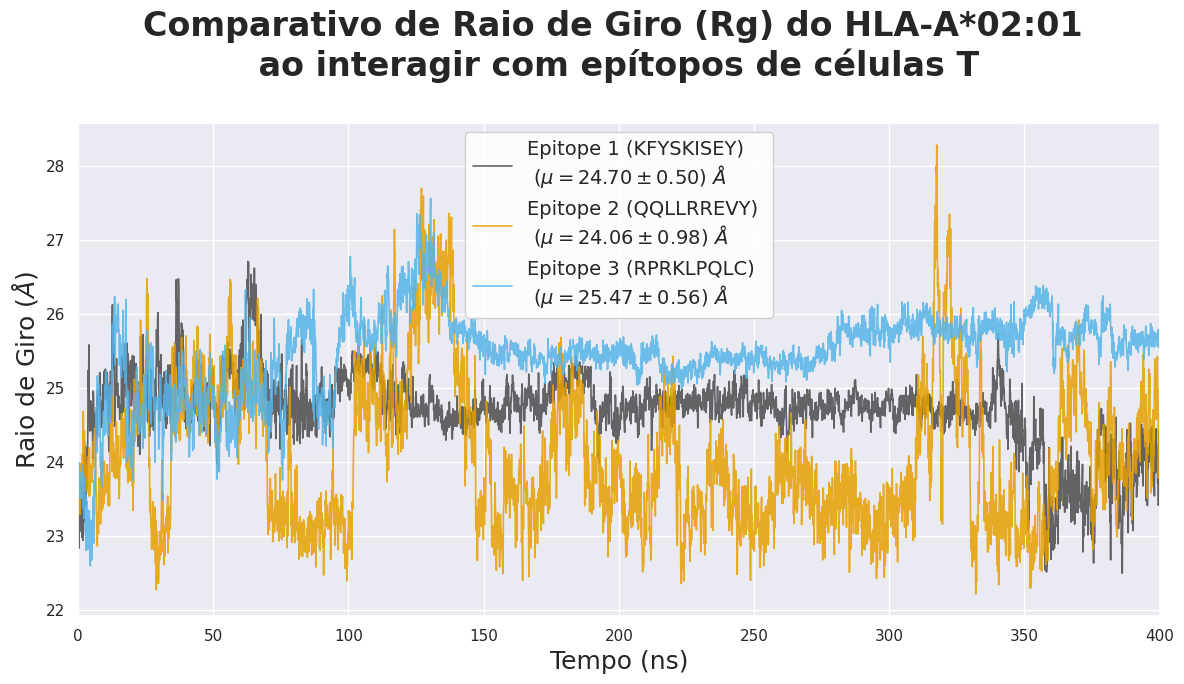

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados de Raio de Giro (Rg) do HLA
df_hla_ep1 = pd.read_csv('rgyr_apenas_4U6Y_HLA-A_02_01_com_epitope_kfyskisey_conf7.csv')
df_hla_ep2 = pd.read_csv('rgyr_apenas_4U6Y_HLA-A_02_01_com_epitope_qqllrrevy_conf10.csv')
df_hla_ep3 = pd.read_csv('rgyr_apenas_4U6Y_HLA-A_02_01_com_epitope_rprklpqlc_conf8.csv')

# Coluna onde está o valor de Raio de Giro
y_col_idx = 2

# --- CORREÇÃO DO TEMPO (Eixo X) ---
# Gera um array de 0 a 400 ns exatamente com o mesmo número de pontos (frames) dos dados
time_ns_ep1 = np.linspace(0, 400, num=len(df_hla_ep1))
time_ns_ep2 = np.linspace(0, 400, num=len(df_hla_ep2))
time_ns_ep3 = np.linspace(0, 400, num=len(df_hla_ep3))

# 2. Calcular estatísticas globais (Média e Desvio Padrão do Rg)
mean_ep1, std_ep1 = df_hla_ep1.iloc[:, y_col_idx].mean(), df_hla_ep1.iloc[:, y_col_idx].std()
mean_ep2, std_ep2 = df_hla_ep2.iloc[:, y_col_idx].mean(), df_hla_ep2.iloc[:, y_col_idx].std()
mean_ep3, std_ep3 = df_hla_ep3.iloc[:, y_col_idx].mean(), df_hla_ep3.iloc[:, y_col_idx].std()

# 3. Criar textos para a legenda com as sequências
# \mu é o símbolo grego para média
label_ep1 = f'Epitope 1 (KFYSKISEY) \n ($\mu={mean_ep1:.2f} \pm {std_ep1:.2f}$) $\AA$'
label_ep2 = f'Epitope 2 (QQLLRREVY) \n ($\mu={mean_ep2:.2f} \pm {std_ep2:.2f}$) $\AA$'
label_ep3 = f'Epitope 3 (RPRKLPQLC) \n ($\mu={mean_ep3:.2f} \pm {std_ep3:.2f}$) $\AA$'

# 4. Configurar estilo Seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 5. Plotar as linhas do Raio de Giro ao longo do tempo
plt.plot(time_ns_ep1, df_hla_ep1.iloc[:, y_col_idx],
         color='#4C4C4C', label=label_ep1, linewidth=1.2, alpha=0.85)

plt.plot(time_ns_ep2, df_hla_ep2.iloc[:, y_col_idx],
         color='#E69F00', label=label_ep2, linewidth=1.2, alpha=0.85)

plt.plot(time_ns_ep3, df_hla_ep3.iloc[:, y_col_idx],
         color='#56B4E9', label=label_ep3, linewidth=1.2, alpha=0.85)

# 6. Estilização final
plt.title('Comparativo de Raio de Giro (Rg) do HLA-A*02:01 \n ao interagir com epítopos de células T \n',
          fontsize=24, fontweight='bold')
plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel(r'Raio de Giro ($\AA$)', fontsize=18)

# Limitar explicitamente o eixo X de 0 a 400
plt.xlim(0, 400)

# Ajuste da legenda (se os valores do HLA forem muito altos, talvez seja necessário mudar o loc)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('rgyr_comparativo_receptor_hla.png', dpi=600)
plt.savefig('rgyr_comparativo_receptor_hla.pdf')
plt.show()